#Sequential Data

Sequence = [29°C, 30°C, 31°C, 30°C, 28°C, 27°C]

Tomorrow’s temperature depends on the sequence of past temperature values.

Words typed = ["Deep", "Learning", "is", "a"]

Google predicts the next word based on this sequence.

#How Feedforward Networks Process Data

Feedforward NN:

Processes each row independently.
Does not remember what it saw before.
Does not care about the order of samples: It does not matter if row 1 comes before row 2 or after.


There is no temporal or sequential relationship between the rows of the dataset.


Feedforward NN expects fixed-length input vectors.

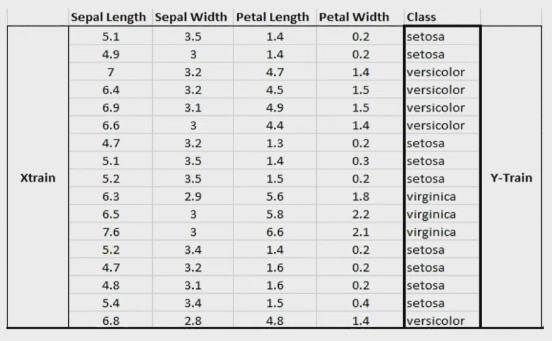

#CNN and Sequential Data

In CNN, the size of the input is always fixed.

Images are resized to a fixed shape (e.g., 64×64 or 128×128) before passing to the model.

CNN also treats each input independently. Each image is processed independently of all others. Here also, during training, images are learned independently, and during testing, predictions depend only on the current image—never on previous inputs.

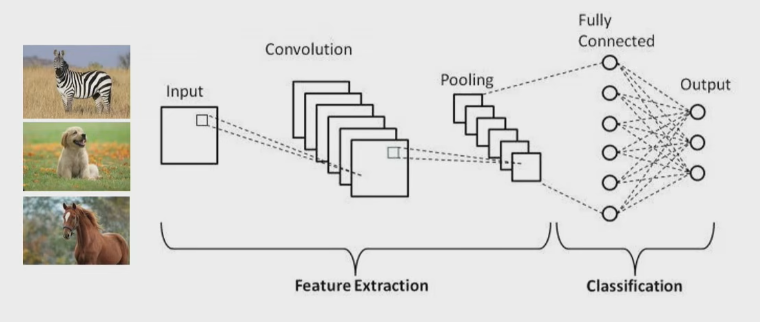

#Problem with Feedforward NN and CNN

Model reads each of these inputs independently.
There is no dependence between the inputs and the size of the input is fixed.
There is no temporal or sequential relationship between inputs.

#Why order matters

**1. Time-Series Example — Sales Record of a Shop**

To predict Monday’s sales, the shop owner must look at the previous pattern or trend.

So, the prediction depends on a sequence of past values.

The inputs are dependent on each other.

Time-Series Example (Sales record of a shop): Yesterday’s sales affect today’s sales.

**Other examples:**

Stock market prediction

Weather forecasting


**2. Text Example**

To predict the next character, the model must remember the previous input.

Input is not independent and the order of input matters.

The previous characters influence the prediction of the next character.


**3. Video / Action Recognition**

A single frame has no meaning.

The action is understood from a sequence of frames.

Order is important and the current input depends on the previous inputs.


**4. Natural Language Example — Google Search Autocomplete**

The model cannot generate the next word without using the earlier words in the sentence.

**For example:**

Deep Learning is ...

Google autocomplete predicts possible continuations based on the words already typed.


This again shows that:

there is a dependency between words
the order of words matters
the next word depends on the previous words

So, in sequence-learning problems:

Current input depends on previous inputs and order of input matters.

**We need to build the model for such applications where:**

The model must handle dependencies between inputs.


The model must handle variable-length inputs.

**To achieve (1) and (2), at each time step, the function executed by the model should be the same.**

#Sequential learning characteristics

#Recurrent Neural Network Architecture

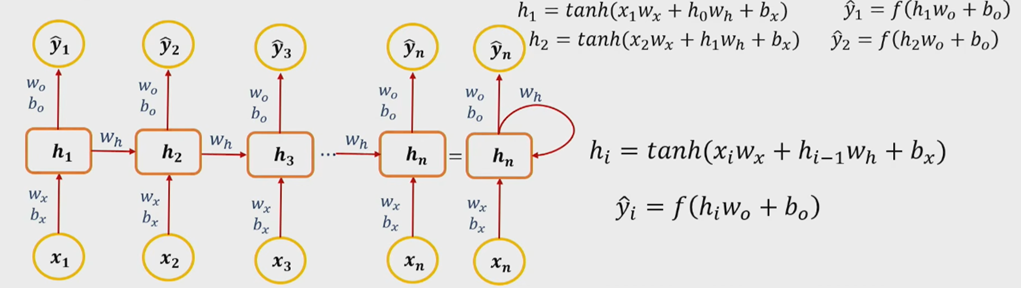

## Types of RNN

| RNN Type | Input | Output | Example |
|---|---|---|---|
| **One-to-One** | Single input | Single output | Temperature prediction |
| **One-to-Many** | Single input | Sequence of outputs | Image captioning, story generation |
| **Many-to-One** | Sequence of inputs | Single output | Sentiment classification, action prediction |
| **Many-to-Many** | Sequence of inputs | Sequence of outputs | Machine translation, video captioning |

In [1]:
from numpy import array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, SimpleRNN, Embedding

In [2]:

# source text

data = """
students learn natural language processing
students study natural language processing
students practice natural language processing
students understand natural language processing concepts
natural language processing helps computers understand text
natural language processing includes text classification
natural language processing includes sentiment analysis
natural language processing includes machine translation
natural language processing includes next word prediction
natural language processing uses machine learning models
the natural language processing laboratory uses python
the natural language processing course includes practical experiments
recurrent neural network processes sequential data
recurrent neural network remembers previous information
recurrent neural network predicts the next word
recurrent neural network learns patterns from sequences
recurrent neural network contains a hidden state
the recurrent neural network reads words in order
the recurrent neural network is useful for sequence modelling
the recurrent neural network trains on token sequences
next word prediction uses previous words
next word prediction is a sequence learning task
next word prediction generates likely continuations
next word prediction requires tokenized text
the next word depends on the previous context
the next word is selected from the vocabulary
the model predicts the next word
the model learns word order
the model learns patterns from training data
the model improves with more training sentences
the model converts context into probabilities
the model produces a probability distribution
the model uses an embedding layer
the model uses a recurrent layer
the model uses a softmax output layer
the model is trained using categorical loss
the model is evaluated using accuracy
the model saves learned parameters
students write python code
students execute python code in the laboratory
students prepare the training dataset
students tokenize the training sentences
students convert words into integer tokens
students create input and target sequences
students train the recurrent neural network
students observe training and validation loss
students plot accuracy and loss graphs
students test different seed phrases
students record the predicted next words
students compare predicted words with expected words
students write observations in the practical journal
students write the conclusion by hand
the teacher explains recurrent neural networks
the teacher explains sequence learning
the teacher demonstrates next word prediction
the teacher provides sample training sentences
the teacher guides students during the experiment
the teacher checks the prediction results
the tokenizer converts words into token identifiers
the tokenizer creates a word vocabulary
the tokenizer assigns a unique number to each word
the embedding layer converts tokens into vectors
the embedding layer learns dense word representations
the recurrent layer processes one token at a time
the hidden state stores previous sequence information
the dense layer predicts vocabulary probabilities
the softmax layer selects likely output words
training data contains input and target pairs
training data should contain repeated language patterns
more training data usually improves prediction
clean text improves vocabulary quality
text cleaning removes unwanted symbols
text preprocessing converts sentences to lowercase
sequence padding creates equal length inputs
padding tokens should be ignored by the model
early stopping prevents unnecessary training
validation loss measures generalization performance
top five accuracy checks multiple likely predictions
machine learning models learn patterns from data
deep learning models use neural networks
language models predict words from context
language models assign probabilities to words
a larger vocabulary makes prediction more difficult
a small vocabulary is suitable for classroom experiments
good training sentences improve model learning
repeated sentence patterns help the model learn
the laboratory experiment demonstrates sequence prediction
the practical experiment uses custom English sentences
the output shows the most likely next word
the prediction function accepts a seed phrase
the prediction function returns likely words
"""

In [4]:
# integer encode text
tokenizer = Tokenizer()
tokenizer.fit_on_texts([data])
encoded_data= tokenizer.texts_to_sequences([data])[0]
print(encoded_data)

[2, 37, 6, 3, 7, 2, 88, 6, 3, 7, 2, 89, 6, 3, 7, 2, 58, 6, 3, 7, 90, 6, 3, 7, 91, 92, 58, 18, 6, 3, 7, 26, 18, 93, 6, 3, 7, 26, 94, 95, 6, 3, 7, 26, 38, 96, 6, 3, 7, 26, 8, 4, 9, 6, 3, 7, 17, 38, 19, 27, 1, 6, 3, 7, 39, 17, 40, 1, 6, 3, 7, 97, 26, 41, 59, 10, 11, 15, 60, 98, 20, 10, 11, 15, 99, 31, 61, 10, 11, 15, 42, 1, 8, 4, 10, 11, 15, 32, 28, 29, 43, 10, 11, 15, 62, 12, 63, 64, 1, 10, 11, 15, 100, 13, 44, 65, 1, 10, 11, 15, 21, 101, 66, 22, 102, 1, 10, 11, 15, 103, 67, 45, 43, 8, 4, 9, 17, 31, 13, 8, 4, 9, 21, 12, 22, 19, 104, 8, 4, 9, 105, 30, 106, 8, 4, 9, 107, 108, 18, 1, 8, 4, 109, 67, 1, 31, 46, 1, 8, 4, 21, 110, 29, 1, 23, 1, 5, 42, 1, 8, 4, 1, 5, 32, 4, 65, 1, 5, 32, 28, 29, 14, 20, 1, 5, 47, 68, 48, 14, 24, 1, 5, 33, 46, 34, 49, 1, 5, 111, 12, 112, 113, 1, 5, 17, 114, 50, 16, 1, 5, 17, 12, 10, 16, 1, 5, 17, 12, 69, 51, 16, 1, 5, 21, 115, 70, 116, 35, 1, 5, 21, 117, 70, 52, 1, 5, 118, 119, 120, 2, 53, 40, 71, 2, 121, 40, 71, 44, 1, 39, 2, 122, 1, 14, 123, 2, 124, 1, 14, 24, 

In [5]:
# determine the vocabulary size
vocab_size = len(tokenizer.word_index) + 1  # 0 is reserved for padding so that's why we added 1

print('Vocabulary Size: %d' % vocab_size)



Vocabulary Size: 207


# Next, we need to create sequences of words to fit the model with one word as input and one word as output.


In [6]:
# create word -> word sequences
sequences = list()
for i in range(1, len(encoded_data)):
	sequence = encoded_data[i-1:i+1]
	sequences.append(sequence)
print('Total Sequences: %d' % len(sequences))
# split into X and y elements


Total Sequences: 585


# Number of Input–Output Training Pairs

The following cells display the word-to-next-word pairs created from the text data.


In [8]:
print(sequences)
#sequences[:5] # [input, output]

[[2, 37], [37, 6], [6, 3], [3, 7], [7, 2], [2, 88], [88, 6], [6, 3], [3, 7], [7, 2], [2, 89], [89, 6], [6, 3], [3, 7], [7, 2], [2, 58], [58, 6], [6, 3], [3, 7], [7, 90], [90, 6], [6, 3], [3, 7], [7, 91], [91, 92], [92, 58], [58, 18], [18, 6], [6, 3], [3, 7], [7, 26], [26, 18], [18, 93], [93, 6], [6, 3], [3, 7], [7, 26], [26, 94], [94, 95], [95, 6], [6, 3], [3, 7], [7, 26], [26, 38], [38, 96], [96, 6], [6, 3], [3, 7], [7, 26], [26, 8], [8, 4], [4, 9], [9, 6], [6, 3], [3, 7], [7, 17], [17, 38], [38, 19], [19, 27], [27, 1], [1, 6], [6, 3], [3, 7], [7, 39], [39, 17], [17, 40], [40, 1], [1, 6], [6, 3], [3, 7], [7, 97], [97, 26], [26, 41], [41, 59], [59, 10], [10, 11], [11, 15], [15, 60], [60, 98], [98, 20], [20, 10], [10, 11], [11, 15], [15, 99], [99, 31], [31, 61], [61, 10], [10, 11], [11, 15], [15, 42], [42, 1], [1, 8], [8, 4], [4, 10], [10, 11], [11, 15], [15, 32], [32, 28], [28, 29], [29, 43], [43, 10], [10, 11], [11, 15], [15, 62], [62, 12], [12, 63], [63, 64], [64, 1], [1, 10], [10, 1

# We can then split the sequences into input (X) and output elements (y)

In [10]:
sequences = array(sequences)
X, y = sequences[:,0],sequences[:,1]

'''
sequences[:, 0]
: means take all rows
0 means take column 0 (first column)

sequences[:, 1]
: means take all rows
1 means take column 1 (second column)
'''

'\nsequences[:, 0]\n: means take all rows\n0 means take column 0 (first column)\n\nsequences[:, 1]\n: means take all rows\n1 means take column 1 (second column)\n'

In [12]:
X[:5]

array([ 2, 37,  6,  3,  7])

In [13]:
y[:5]

array([37,  6,  3,  7,  2])

In [14]:
# one hot encode outputs
y = to_categorical(y, num_classes=vocab_size) #Convert each target word ID in y into a one-hot vector whose length is equal to vocab_size.
# define model
y[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(5, 207))

In [24]:


model = Sequential()

# Input contains one token/word.
model.add(Input(shape=(1,)))

# Convert each word ID into a vector of 10 numbers.
model.add(Embedding(
    vocab_size,
    10

))

# RNN remembers information using 50 hidden units.
model.add(SimpleRNN(50))

# Predict one probability for every word in vocabulary.
model.add(Dense(
    vocab_size,
    activation='softmax'
))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1, 10)          │         2,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         3,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 207)            │        10,557 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,677 (61.24 KB)

 Trainable params: 15,677 (61.24 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# compile network
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



In [17]:
# fit network
# history stores loss and accuracy values for every epoch.
# validation_split=0.20 keeps 20% of the available pairs for validation.
history = model.fit(
    X,
    y,
    epochs=100,
    validation_split=0.20,
    verbose=1
)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0107 - loss: 5.3264 - val_accuracy: 0.0256 - val_loss: 5.3280
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0940 - loss: 5.3013 - val_accuracy: 0.0598 - val_loss: 5.3245
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1004 - loss: 5.2678 - val_accuracy: 0.0684 - val_loss: 5.3192
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1004 - loss: 5.2149 - val_accuracy: 0.0684 - val_loss: 5.3121
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1004 - loss: 5.1372 - val_accuracy: 0.0684 - val_loss: 5.3042
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1004 - loss: 5.0220 - val_accuracy: 0.0684 - val_loss: 5.3019
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1004 - loss: 4.8715 - val_accuracy: 0.0684 - val_loss: 5.3088
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1004 - loss: 4.6998 - val_accuracy: 0.0684 - 

In [ ]:
from numpy import array
import numpy as np
# Generate a sequence from the trained model
def generate_seq(model, tokenizer, enter_text, n_pred):
    # Starting word
    in_text = enter_text
    # Store complete generated output
    result = enter_text
    # Generate n_pred number of words
    for _ in range(n_pred):
        # Step 1: Convert input word into integer
        encoded = tokenizer.texts_to_sequences([in_text])[0]
        # Step 2: Convert into NumPy array
        # Shape should be (1, 1) because model takes one word as input
        encoded = array(encoded).reshape(1, 1)
        # Step 3: Predict probability of every word
        prediction = model.predict(encoded, verbose=0)
        # Step 4: Select word having maximum probability
        yhat = np.argmax(prediction, axis=1)[0]
        # Step 5: Convert predicted word number back to word
        out_word = tokenizer.index_word.get(yhat, '')
        # If no word is found, stop prediction
        if out_word == '': break
        # Step 6: Predicted word becomes next input
        in_text = out_word
        # Add predicted word to result
        result = result + ' ' + out_word
    return result

In [19]:
# evaluate
print(generate_seq(model, tokenizer, 'natural', 3))

natural language processing includes


In [20]:

print(generate_seq(model, tokenizer, 'recurrent', 3))

recurrent neural network contains


# Final Experiment Results

The following section reports:

- Vocabulary size
- Number of training pairs
- Model summary
- Training and validation loss curves
- Training and validation accuracy curves



In [21]:
# ---------------------------------------------------------
# 1. Vocabulary Size, Number of Training Pairs, Model Summary
# ---------------------------------------------------------

print("Vocabulary Size:", vocab_size)
print("Number of Input-Output Pairs:", len(X))

print("\nModel Summary:")
model.summary()


Vocabulary Size: 207
Number of Input-Output Pairs: 585

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1, 10)          │         2,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         3,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 207)            │        10,557 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,033 (183.73 KB)

 Trainable params: 15,677 (61.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 31,356 (122.49 KB)

## Training and Validation Loss / Accuracy

During `model.fit()`:

- **Training loss** shows the error on data used to update model weights.
- **Validation loss** shows the error on the held-out validation portion.
- **Training accuracy** shows the percentage of correct next-word predictions on training data.
- **Validation accuracy** shows performance on validation data.

These curves help us observe whether the model is learning and whether it may be overfitting.


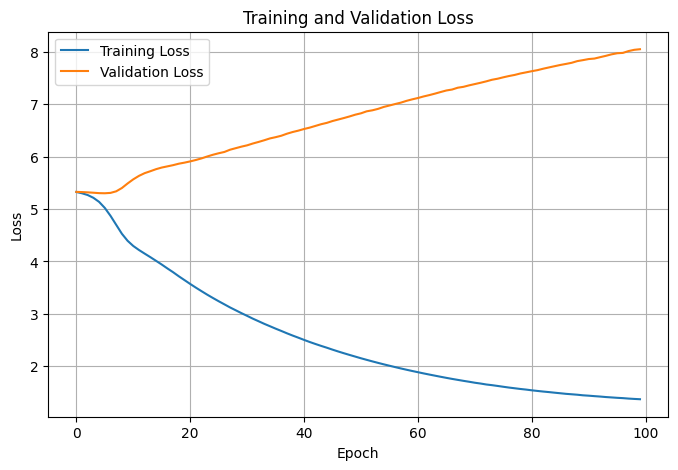

In [ ]:
# ---------------------------------------------------------
# 2. Training and Validation Loss Curve
# ---------------------------------------------------------

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    history.history['loss'],
    label='Training Loss'
)
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()


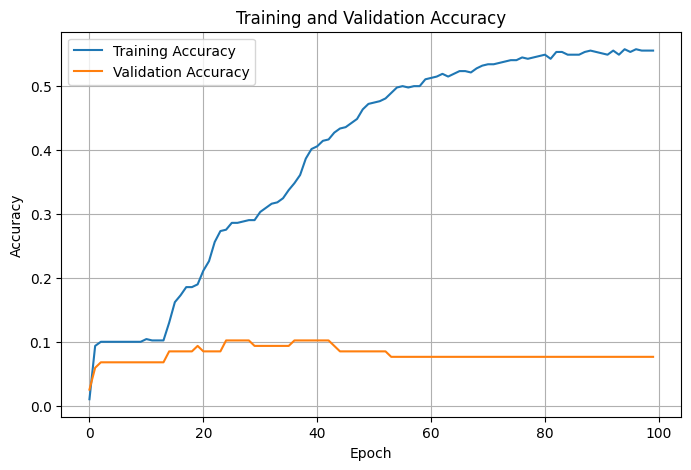

In [ ]:
# ---------------------------------------------------------
# 3. Training and Validation Accuracy Curve
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()
plt.show()


# Exercise: RNN Next-Word Prediction Using Shakespeare Dataset

## Objective

In the previous experiment, we trained a Recurrent Neural Network (RNN) using a small set of **custom English sentences** for next-word prediction.

In this exercise, use the **Shakespeare text dataset** and repeat the next-word prediction experiment.

The purpose of this exercise is to understand how the size and variety of training data affect:

- Vocabulary size
- Number of training pairs
- Training and validation performance
- Next-word predictions


---



#Use the following code to download and read the Shakespeare dataset:

```python
DATA_URL = (
    "https://storage.googleapis.com/download.tensorflow.org/"
    "data/shakespeare.txt"
)

path_to_file = tf.keras.utils.get_file(
    fname="shakespeare.txt",
    origin=DATA_URL
)

with open(path_to_file, "r", encoding="utf-8") as file:
    raw_text = file.read()

print("Total characters:", len(raw_text))

print("\nDataset sample:\n")
print(raw_text[:1000])

#Students should submit:

Aim of Experiment (Handwritten)

Python code with results and graphs (print)

Conclusion (Handwritten)